##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


TensorFlow version: 2.16.2
Model loaded successfully!
Image 1: /Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab05-object-segmentation/brocolli.jpeg
Threshold = 0.5


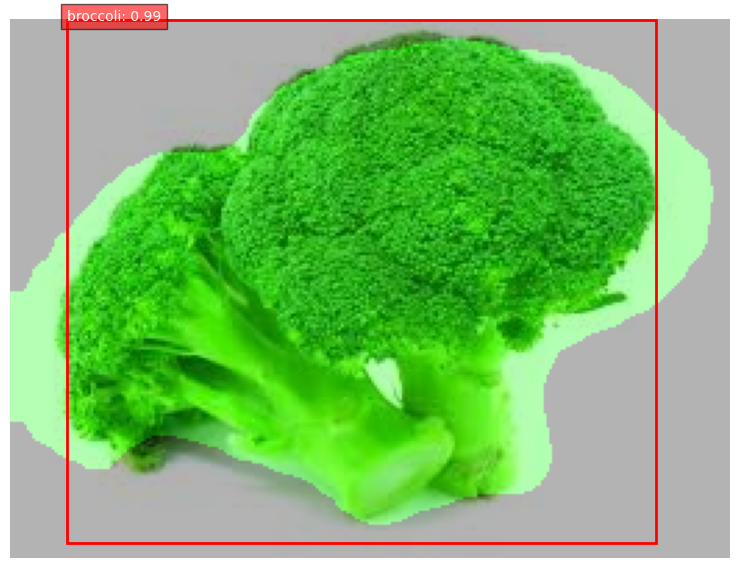

Threshold = 0.3


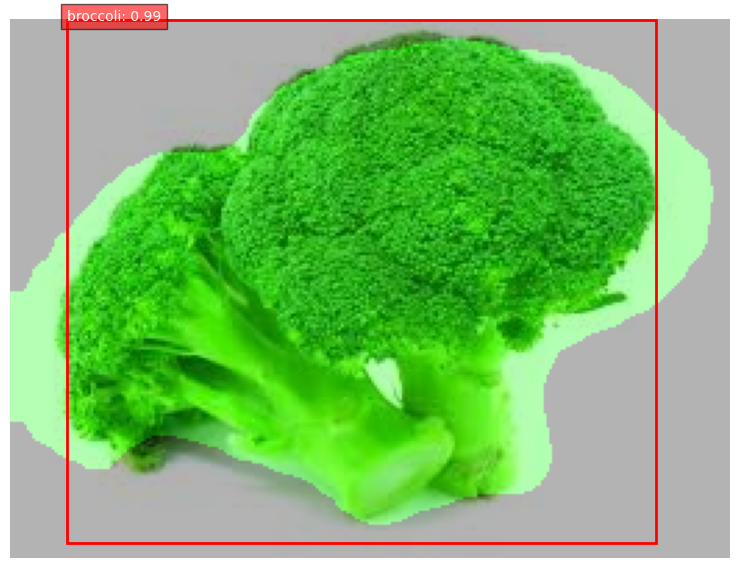

Image 2: /Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab05-object-segmentation/cow with background.jpeg
Threshold = 0.5


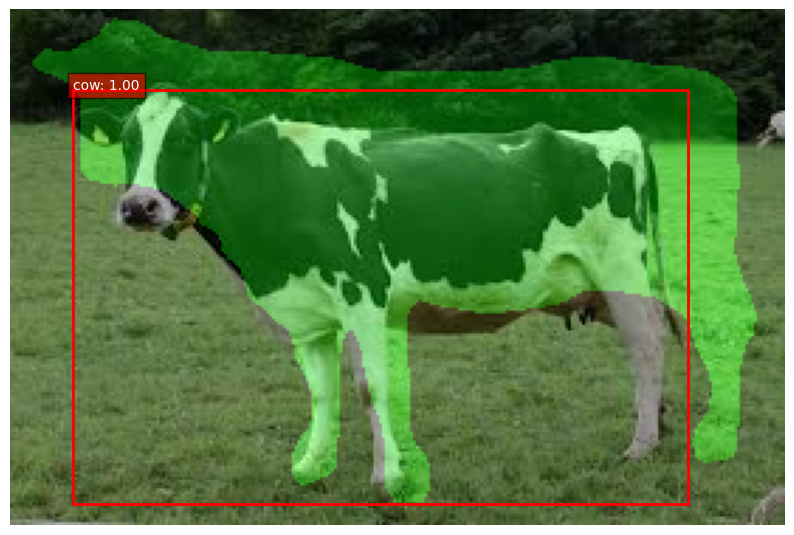

Threshold = 0.3


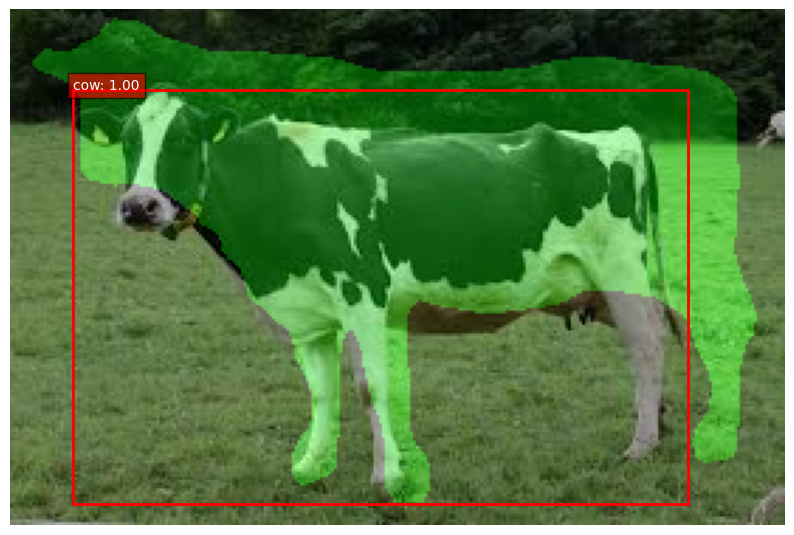

Image 3: /Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab05-object-segmentation/kayboardontable.jpeg
Threshold = 0.5


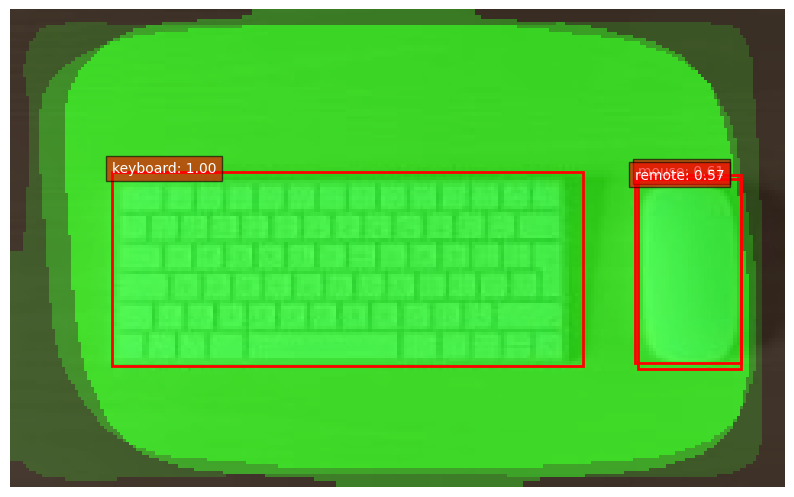

Threshold = 0.3


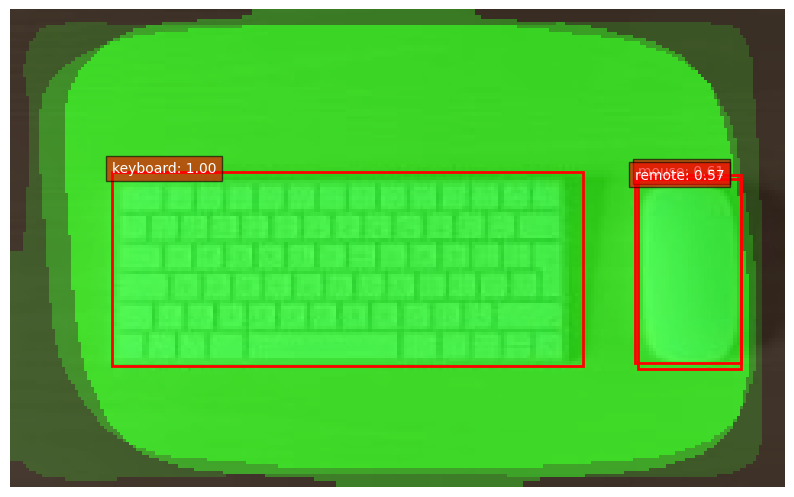

Image 4: /Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab05-object-segmentation/hairdryeerrr.jpeg
Threshold = 0.5


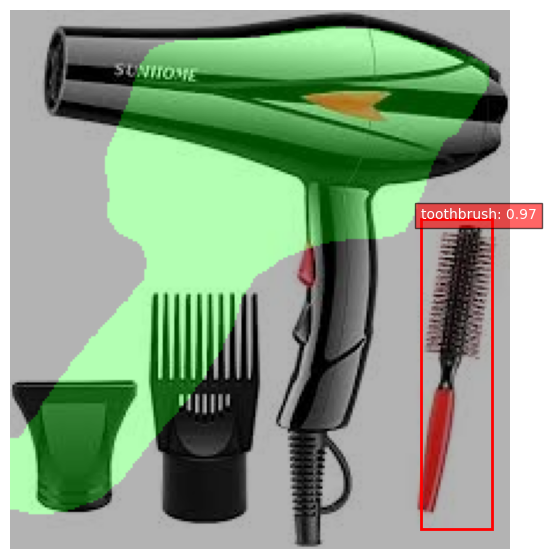

Threshold = 0.3


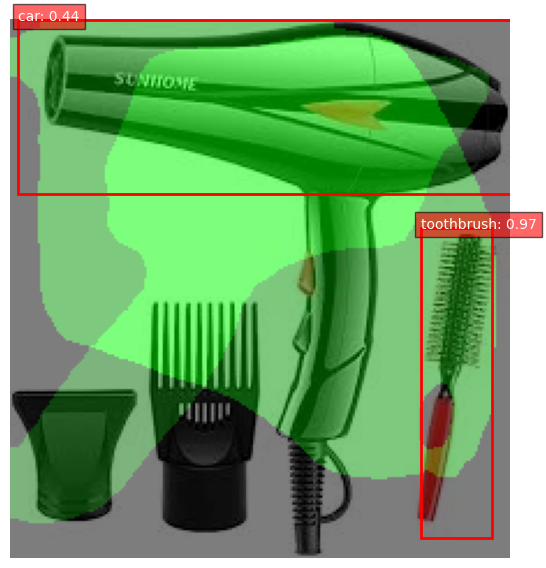

Image 5: /Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab05-object-segmentation/scissorswithother.jpeg
Threshold = 0.5


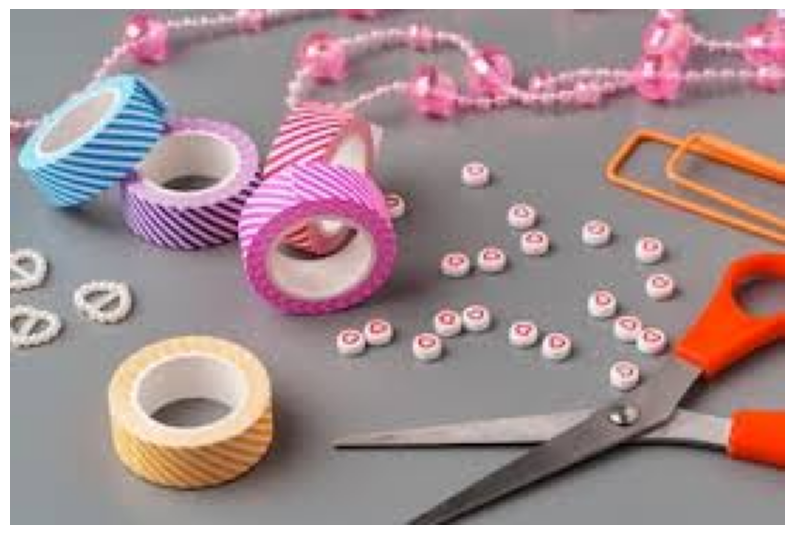

Threshold = 0.3


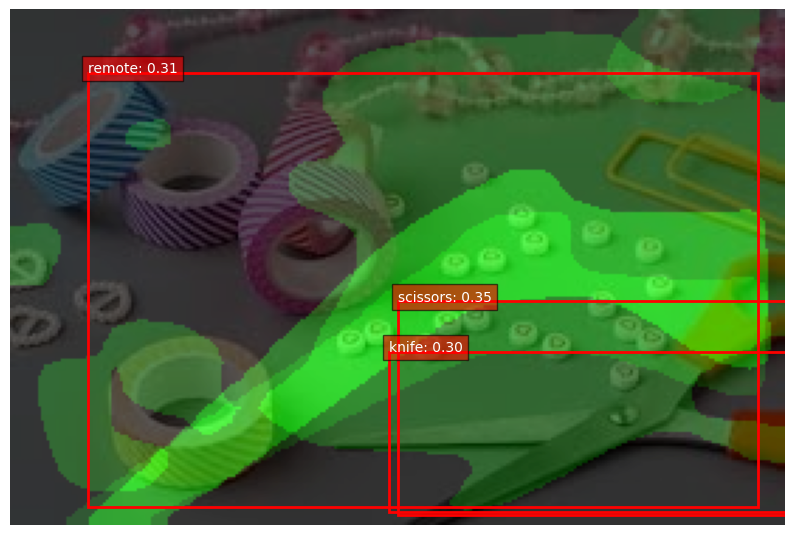

In [2]:
import cv2

!pip install -q tensorflow tensorflow-hub matplotlib opencv-python pillow

import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

print("TensorFlow version:", tf.__version__)

# loading the pretrained model
model_handle = "https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1"
detector = hub.load(model_handle)
print("Model loaded successfully!")

# coco labels
coco_labels = {
    1: "person", 2: "bicycle", 3: "car", 4: "motorcycle", 5: "airplane",
    6: "bus", 7: "train", 8: "truck", 9: "boat", 10: "traffic light",
    11: "fire hydrant", 13: "stop sign", 14: "parking meter", 15: "bench",
    16: "bird", 17: "cat", 18: "dog", 19: "horse", 20: "sheep",
    21: "cow", 22: "elephant", 23: "bear", 24: "zebra", 25: "giraffe",
    27: "backpack", 28: "umbrella", 31: "handbag", 32: "tie", 33: "suitcase",
    34: "frisbee", 35: "skis", 36: "snowboard", 37: "sports ball",
    38: "kite", 39: "baseball bat", 40: "baseball glove", 41: "skateboard",
    42: "surfboard", 43: "tennis racket", 44: "bottle", 46: "wine glass",
    47: "cup", 48: "fork", 49: "knife", 50: "spoon", 51: "bowl",
    52: "banana", 53: "apple", 54: "sandwich", 55: "orange", 56: "broccoli",
    57: "carrot", 58: "hot dog", 59: "pizza", 60: "donut", 61: "cake",
    62: "chair", 63: "couch", 64: "potted plant", 65: "bed", 67: "dining table",
    70: "toilet", 72: "tv", 73: "laptop", 74: "mouse", 75: "remote",
    76: "keyboard", 77: "cell phone", 78: "microwave", 79: "oven",
    80: "toaster", 81: "sink", 82: "refrigerator", 84: "book", 85: "clock",
    86: "vase", 87: "scissors", 88: "teddy bear", 89: "hair drier",
    90: "toothbrush"
}

# loading the images from local files
def load_image(path):
    image = Image.open(path).convert("RGB")
    return np.array(image)

image_paths = [
    "/Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab05-object-segmentation/brocolli.jpeg",
    "/Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab05-object-segmentation/cow with background.jpeg",
    "/Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab05-object-segmentation/kayboardontable.jpeg",
    "/Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab05-object-segmentation/hairdryeerrr.jpeg",
    "/Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab05-object-segmentation/scissorswithother.jpeg"
]

images = [load_image(path) for path in image_paths]

# run inference
def run_inference(image_np):
    input_tensor = tf.convert_to_tensor(image_np, dtype=tf.uint8)
    input_tensor = tf.expand_dims(input_tensor, axis=0)
    outputs = detector(input_tensor)
    return {k: v.numpy() for k, v in outputs.items()}

# converting
def reframe_box_masks_to_image_masks(box_masks, boxes, image_height, image_width):
    box_masks = tf.expand_dims(box_masks, axis=3)

    image_masks = tf.image.crop_and_resize(
        image=box_masks,
        boxes=boxes,
        box_indices=tf.range(tf.shape(box_masks)[0]),
        crop_size=[image_height, image_width]
    )

    return tf.squeeze(image_masks, axis=3)

# visualizations
def draw_results(image_np, outputs, threshold=0.5):
    image_vis = image_np.copy()
    h, w, _ = image_vis.shape

    boxes = outputs["detection_boxes"][0]
    classes = outputs["detection_classes"][0].astype(np.int32)
    scores = outputs["detection_scores"][0]
    masks = outputs["detection_masks"][0]

    valid = scores >= threshold

    boxes = boxes[valid]
    classes = classes[valid]
    scores = scores[valid]
    masks = masks[valid]

    fig, ax = plt.subplots(1, figsize=(10, 7))
    ax.imshow(image_vis)

    for i in range(len(boxes)):
        ymin, xmin, ymax, xmax = boxes[i]
        x1, y1 = int(xmin * w), int(ymin * h)
        x2, y2 = int(xmax * w), int(ymax * h)

        # Draw box
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)

        # Label
        label = coco_labels.get(classes[i], "Unknown")
        ax.text(
            x1, y1, f"{label}: {scores[i]:.2f}",
            color='white',
            bbox=dict(facecolor='red', alpha=0.6)
        )

        # Mask
        mask = masks[i]
        mask = cv2.resize(mask, (w, h))
        mask = mask > 0.5

        colored_mask = np.zeros_like(image_vis)
        colored_mask[:, :, 1] = mask * 255

        ax.imshow(colored_mask, alpha=0.3)

    ax.axis("off")
    plt.show()

# running for all images
for i, image_np in enumerate(images):
    print("=" * 50)
    print(f"Image {i+1}: {image_paths[i]}")

    outputs = run_inference(image_np)

    print("Threshold = 0.5")
    draw_results(image_np, outputs, threshold=0.5)

    print("Threshold = 0.3")
    draw_results(image_np, outputs, threshold=0.3)